In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("agungpambudi/network-malware-detection-connection-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'network-malware-detection-connection-analysis' dataset.
Path to dataset files: /kaggle/input/network-malware-detection-connection-analysis


# ***Part 1***

In [2]:
# Install required libraries
!pip install pandasql
!pip install kaggle

# Mount Google Drive to save/access your Kaggle API token
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import os

# Path to your dataset
data_dir = "/root/.cache/kagglehub/datasets/agungpambudi/network-malware-detection-connection-analysis/versions/3"
file_name = "CTU-IoT-Malware-Capture-1-1conn.log.labeled.csv"
file_path = os.path.join(data_dir, file_name)

# 4) Read the csv file using the correct separator
df = pd.read_csv(file_path, sep='|')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008748 entries, 0 to 1008747
Data columns (total 23 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   ts              1008748 non-null  float64
 1   uid             1008748 non-null  object 
 2   id.orig_h       1008748 non-null  object 
 3   id.orig_p       1008748 non-null  float64
 4   id.resp_h       1008748 non-null  object 
 5   id.resp_p       1008748 non-null  float64
 6   proto           1008748 non-null  object 
 7   service         1008748 non-null  object 
 8   duration        1008748 non-null  object 
 9   orig_bytes      1008748 non-null  object 
 10  resp_bytes      1008748 non-null  object 
 11  conn_state      1008748 non-null  object 
 12  local_orig      1008748 non-null  object 
 13  local_resp      1008748 non-null  object 
 14  missed_bytes    1008748 non-null  float64
 15  history         1008748 non-null  object 
 16  orig_pkts       1008748 non-null  fl

In [4]:
# Rename specific columns exactly as requested in the project requirements
df.rename(columns={
    'id.orig_h': 'Source_IP',
    'id.resp_h': 'Destination_IP',
    'id.orig_p': 'Source_Port',
    'id.resp_p': 'Destination_Port',
    'detailed-label': 'detailed_label'
}, inplace=True)

# Define the new names to cast to string [cite: 18]
string_cols = ['Source_IP', 'Destination_IP', 'Source_Port', 'Destination_Port', 'detailed_label']

# Check if the new names exist in df before casting to avoid KeyError
existing_string_cols = [c for c in string_cols if c in df.columns]

if len(existing_string_cols) == len(string_cols):
    df[string_cols] = df[string_cols].astype(str)
    print("Columns successfully renamed and cast to string.")
else:
    missing = set(string_cols) - set(df.columns)
    print(f"Warning: These columns were not found after renaming: {missing}")

Columns successfully renamed and cast to string.


# ***Part 2***

In [5]:
from pandasql import sqldf

# Helper function for pandasql
pysqldf = lambda q: sqldf(q, globals())

# SQL Query for Top 20 Benign IP pairs
query_1 = """
SELECT
    Source_IP,
    Destination_IP,
    COUNT(*) as connection_count
FROM df
WHERE label = 'Benign'
  AND (orig_bytes > 0 OR resp_bytes > 0)
GROUP BY Source_IP, Destination_IP
ORDER BY connection_count DESC
LIMIT 20
"""

top_20_benign_ips = pysqldf(query_1)
print(top_20_benign_ips)

          Source_IP   Destination_IP  connection_count
0   192.168.100.103    147.231.100.5              3849
1   192.168.100.103   89.221.214.130               995
2     192.168.100.1  192.168.100.103               949
3   192.168.100.103    37.187.104.44               938
4   192.168.100.103   213.239.154.12               785
5   210.206.154.134  192.168.100.103                 9
6     146.94.254.33  192.168.100.103                 6
7      70.45.29.240  192.168.100.103                 5
8    118.163.192.88  192.168.100.103                 4
9    125.125.23.137  192.168.100.103                 4
10     175.196.5.46  192.168.100.103                 3
11    181.48.215.81  192.168.100.103                 3
12     221.5.224.77  192.168.100.103                 3
13    81.130.230.46  192.168.100.103                 3
14    106.185.21.98  192.168.100.103                 2
15  108.167.134.114  192.168.100.103                 2
16   116.213.53.130  192.168.100.103                 2
17   161.1

In [6]:
# SQL Query for Top 20 Malicious IP pairs
query_2 = """
SELECT
    Source_IP,
    Destination_IP,
    COUNT(*) as attack_count
FROM df
WHERE label = 'Malicious'
  AND (orig_bytes > 0 OR resp_bytes > 0)
GROUP BY Source_IP, Destination_IP
ORDER BY attack_count DESC
LIMIT 20
"""

top_20_malicious_ips = pysqldf(query_2)
print(top_20_malicious_ips)

          Source_IP   Destination_IP  attack_count
0   192.168.100.103  104.224.253.146           121
1   192.168.100.103   108.228.135.74           121
2   192.168.100.103    111.56.57.165           121
3   192.168.100.103     112.54.7.236           121
4   192.168.100.103   118.232.125.43           121
5   192.168.100.103     119.6.201.10           121
6   192.168.100.103   120.26.110.145           121
7   192.168.100.103    120.27.26.196           121
8   192.168.100.103  123.124.198.146           121
9   192.168.100.103   123.184.74.205           121
10  192.168.100.103   137.221.16.255           121
11  192.168.100.103     14.40.48.196           121
12  192.168.100.103     14.53.198.58           121
13  192.168.100.103    141.126.72.48           121
14  192.168.100.103   160.177.85.249           121
15  192.168.100.103   170.104.24.192           121
16  192.168.100.103     171.91.73.45           121
17  192.168.100.103   175.182.77.163           121
18  192.168.100.103   177.69.15

3. Justify that Source_IP and Destination_IP columns should be removed.

Overfitting Risk: IP addresses are specific identifiers for unique hosts in a capture environment; if a model "learns" that a specific IP is malicious, it will fail to generalize to new, unseen attacks from different IP addresses in the real world.

High Cardinality: Categorical features like IP addresses can have thousands of unique values, which creates extremely sparse data that slows down training and complicates the Decision Tree splits.

Lack of Behavioral Insight: Machine learning models for network security should focus on how a connection behaves (duration, bytes, ports, state) rather than who is connecting, as attackers frequently rotate their IP addresses to evade detection.

In [7]:
# SQL Query for Benign Port Pairs
query_4 = """
SELECT
    Source_Port,
    Destination_Port,
    COUNT(*) as connection_count
FROM df
WHERE label = 'Benign'
  AND (orig_bytes > 0 OR resp_bytes > 0)
GROUP BY Source_Port, Destination_Port
ORDER BY connection_count DESC
"""

benign_port_pairs = pysqldf(query_4)
print(benign_port_pairs.head(20))

   Source_Port Destination_Port  connection_count
0        123.0            123.0              6567
1          3.0              1.0              1552
2         11.0              0.0                42
3          3.0             13.0                10
4          3.0              3.0                 6
5         23.0          48504.0                 3
6          3.0             10.0                 3
7         23.0          33515.0                 1
8         23.0          33712.0                 1
9         23.0          33817.0                 1
10        23.0          34213.0                 1
11        23.0          34255.0                 1
12        23.0          34290.0                 1
13        23.0          34592.0                 1
14        23.0          35291.0                 1
15        23.0          35407.0                 1
16        23.0          35671.0                 1
17        23.0          35812.0                 1
18        23.0          35964.0                 1


In [8]:
# SQL Query for Top 20 Malicious Port Pairs
query_5 = """
SELECT
    Source_Port,
    Destination_Port,
    COUNT(*) as attack_count
FROM df
WHERE label = 'Malicious'
  AND (orig_bytes > 0 OR resp_bytes > 0)
GROUP BY Source_Port, Destination_Port
ORDER BY attack_count DESC
LIMIT 20
"""

top_20_malicious_ports = pysqldf(query_5)
print(top_20_malicious_ports)

   Source_Port Destination_Port  attack_count
0      48308.0             23.0             4
1      54527.0             23.0             4
2      33406.0             23.0             3
3      33414.0             23.0             3
4      41248.0           8080.0             3
5      41249.0           8080.0             3
6      41254.0           8080.0             3
7      41256.0           8080.0             3
8      41259.0           8080.0             3
9      41318.0           8080.0             3
10     41320.0           8080.0             3
11     41322.0           8080.0             3
12     41323.0           8080.0             3
13     41325.0           8080.0             3
14     41330.0           8080.0             3
15     41332.0           8080.0             3
16     41335.0           8080.0             3
17     41338.0           8080.0             3
18     41339.0           8080.0             3
19     41340.0           8080.0             3


6. Based on the above two steps, justify Source_Port and Destimation_Port columns should
be removed.

Port Spoofing/Randomization: Many modern malware variants use dynamic or random source ports to evade detection, making specific port numbers unreliable for future classification.


Overfitting to Testbed Data: In a controlled testbed environment, specific ports might be tied to the attack script used, but these same ports may be used for legitimate services in other network environments.


Cardinality: With over 65,000 possible port numbers, treating them as categorical features creates excessive complexity and deep, inefficient branches in a decision tree.

In [9]:
# List of columns to clean
clean_cols = ['local_orig', 'local_resp', 'missed_bytes', 'tunnel_parents']

# Replace '-' with 0 and ensure they are numeric for the next SQL step
for col in clean_cols:
    df[col] = df[col].replace('-', 0)
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print("Replacement complete for: ", clean_cols)

/tmp/ipykernel_33983/410521248.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace('-', 0)


Replacement complete for:  ['local_orig', 'local_resp', 'missed_bytes', 'tunnel_parents']


In [10]:
# SQL Query to find totals for the cleaned columns
query_8 = """
SELECT
    label,
    SUM(local_orig) as total_local_orig,
    SUM(local_resp) as total_local_resp,
    SUM(missed_bytes) as total_missed_bytes,
    SUM(tunnel_parents) as total_tunnel_parents
FROM df
GROUP BY label
"""

totals_by_label = pysqldf(query_8)
print(totals_by_label)

       label  total_local_orig  total_local_resp  total_missed_bytes  \
0     Benign                 0                 0                 0.0   
1  Malicious                 0                 0                 0.0   

   total_tunnel_parents  
0                     0  
1                     0  


9. Based on the above three steps, justify that 4 columns: local_orign, local_resp,
missed_bytes, tunnel_parents should be removed.

Zero or Constant Values: In many IoT malware datasets, these columns often contain all zeros or the same value for both benign and malicious traffic, offering no predictive power to the decision tree.


Feature Redundancy: If these columns show the same distribution for both labels, they do not help the model split the data efficiently, leading to a more complex tree without any gain in accuracy.

10.  Two columns: ts (timestamp) and uid (unique identifier for the connection) should be
removed. Why?

Timestamp (ts): Using specific timestamps causes the model to overfit to the exact time the capture occurred; an attack is malicious because of its behavior, not because it happened at 2:00 PM on a Tuesday.


Unique Identifier (uid): The UID is a random string assigned to every single connection; since every row has a different UID, the model cannot learn a generalizable pattern from it.

In [11]:
# 11) Remove 11 columns and keep 12
# Note: Ensure you've performed the renames from Step 5 first
cols_to_remove = ['Source_IP', 'Destination_IP', 'Source_Port', 'Destination_Port',
                  'local_orig', 'local_resp', 'missed_bytes', 'tunnel_parents',
                  'ts', 'uid', 'detailed_label']

# Only drop if they exist in the dataframe
df_reduced = df.drop(columns=[c for c in cols_to_remove if c in df.columns])

In [12]:
# 12) Replace '-' with 0 for service, duration, orig_bytes, resp_bytes
cols_to_fix = ['service', 'duration', 'orig_bytes', 'resp_bytes']
for col in cols_to_fix:
    df_reduced[col] = df_reduced[col].replace('-', 0)
    # Ensure they are numerical where appropriate
    if col != 'service':
        df_reduced[col] = pd.to_numeric(df_reduced[col], errors='coerce').fillna(0)

In [13]:
# SQL to count attacks and benign connections per state
query_13 = """
SELECT
    conn_state,
    SUM(CASE WHEN label = 'Malicious' THEN 1 ELSE 0 END) AS Num_attacks,
    SUM(CASE WHEN label = 'Benign' THEN 1 ELSE 0 END) AS Num_benign
FROM df_reduced
GROUP BY conn_state
"""

conn_state_df = pysqldf(query_13)
print(conn_state_df)

   conn_state  Num_attacks  Num_benign
0         OTH            0       17421
1         REJ         3918         428
2        RSTO           47           0
3      RSTOS0            9         188
4        RSTR         1459           6
5       RSTRH           45          21
6          S0       526634      444595
7          S1           25           2
8          S2           37           3
9          SF         7277        6604
10         SH           22           7


In [14]:
# SQL to count attacks and benign connections per history pattern
query_14 = """
SELECT
    history,
    SUM(CASE WHEN label = 'Malicious' THEN 1 ELSE 0 END) AS Num_attacks,
    SUM(CASE WHEN label = 'Benign' THEN 1 ELSE 0 END) AS Num_benign
FROM df_reduced
GROUP BY history
"""

history_df = pysqldf(query_14)
print(history_df.head(10))

  history  Num_attacks  Num_benign
0       -            0       17421
1      Ar            0          21
2       D           34      401572
3      D^            0          18
4      Dd            0        6569
5       F           19           5
6      Fa            3           2
7    FaAr            0           2
8     FaR            2           1
9     FfA            1           0


In [15]:
# Map any history value that isn't 'S' or 'Sr' to 'Others'
df_reduced['history'] = df_reduced['history'].apply(lambda x: x if x in ['S', 'Sr'] else 'Others')

# Verification of the mapping
print(df_reduced['history'].value_counts())

history
S         569605
Others    434797
Sr          4346
Name: count, dtype: int64


In [16]:
# SQL to count attacks and benign connections per protocol
query_16 = """
SELECT
    proto,
    SUM(CASE WHEN label = 'Malicious' THEN 1 ELSE 0 END) AS Num_attacks,
    SUM(CASE WHEN label = 'Benign' THEN 1 ELSE 0 END) AS Num_benign
FROM df_reduced
GROUP BY proto
"""

proto_df = pysqldf(query_16)
print(proto_df)

  proto  Num_attacks  Num_benign
0  icmp            0       17421
1   tcp       539439       43695
2   udp           34      408159


In [17]:
# SQL to calculate probability for each protocol
query_17 = """
SELECT
    proto,
    Num_attacks,
    Num_benign,
    CAST(Num_attacks AS FLOAT) / (Num_attacks + Num_benign) AS probability
FROM proto_df
"""

proto_with_prob = pysqldf(query_17)
print(proto_with_prob)

  proto  Num_attacks  Num_benign  probability
0  icmp            0       17421     0.000000
1   tcp       539439       43695     0.925069
2   udp           34      408159     0.000083


In [18]:
import numpy as np

# SQL to calculate entropy using the probabilities
# Note: LOG2 is used for bits of information
query_18 = """
SELECT
    proto,
    Num_attacks,
    Num_benign,
    probability,
    CASE
        WHEN probability = 0 OR probability = 1 THEN 0
        ELSE -(probability * (LOG(probability)/LOG(2))) - ((1-probability) * (LOG(1-probability)/LOG(2)))
    END AS entropy
FROM proto_with_prob
"""

proto_with_entropy = pysqldf(query_18)
print(proto_with_entropy)

  proto  Num_attacks  Num_benign  probability   entropy
0  icmp            0       17421     0.000000  0.000000
1   tcp       539439       43695     0.925069  0.384063
2   udp           34      408159     0.000083  0.001249


In [19]:
from sklearn.preprocessing import LabelEncoder

# 19) Convert string labels to integers
le = LabelEncoder()
# We include 'service' here to prevent the Decision Tree from crashing later
for col in ['conn_state', 'history', 'proto', 'service']:
    df_reduced[col] = le.fit_transform(df_reduced[col].astype(str))


In [20]:
# 20) Convert 'Benign' and 'Malicious' to 0 and 1
# We strip whitespace to ensure the mapping finds the strings
df_reduced['label'] = df_reduced['label'].astype(str).str.strip()
df_reduced['label'] = df_reduced['label'].map({'Benign': 0, 'Malicious': 1})

# Check if any 0s or 1s actually exist now
print(df_reduced['label'].value_counts())

label
1    539473
0    469275
Name: count, dtype: int64


Data distribution before downsampling:
label
1    539473
0    469275
Name: count, dtype: int64


/tmp/ipykernel_33983/1325929154.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


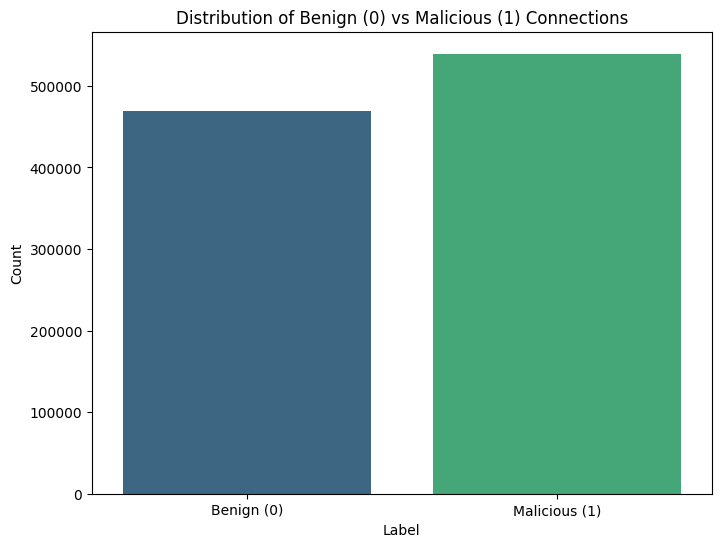

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of data rows for each category (0 = Benign, 1 = Malicious) [cite: 46, 47]
label_counts = df_reduced['label'].value_counts()
print("Data distribution before downsampling:")
print(label_counts)

# Plot using barplot
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Benign (0) vs Malicious (1) Connections')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Benign (0)', 'Malicious (1)'])
plt.show()

In [22]:
from sklearn.utils import resample

# 22) Downsample the data
df_benign = df_reduced[df_reduced['label'] == 0]
df_malicious = df_reduced[df_reduced['label'] == 1]

# This line was failing because n_samples was 0; it should work now
n_samples = min(len(df_benign), len(df_malicious))

df_benign_ds = resample(df_benign, replace=False, n_samples=n_samples, random_state=42)
df_malicious_ds = resample(df_malicious, replace=False, n_samples=n_samples, random_state=42)
df_balanced = pd.concat([df_benign_ds, df_malicious_ds])


In [23]:
# 23) Save to features (11 columns) and target (1 column) [cite: 49, 50]
features = df_balanced.drop(columns=['label'])
target = df_balanced['label']

# ***Part 3***

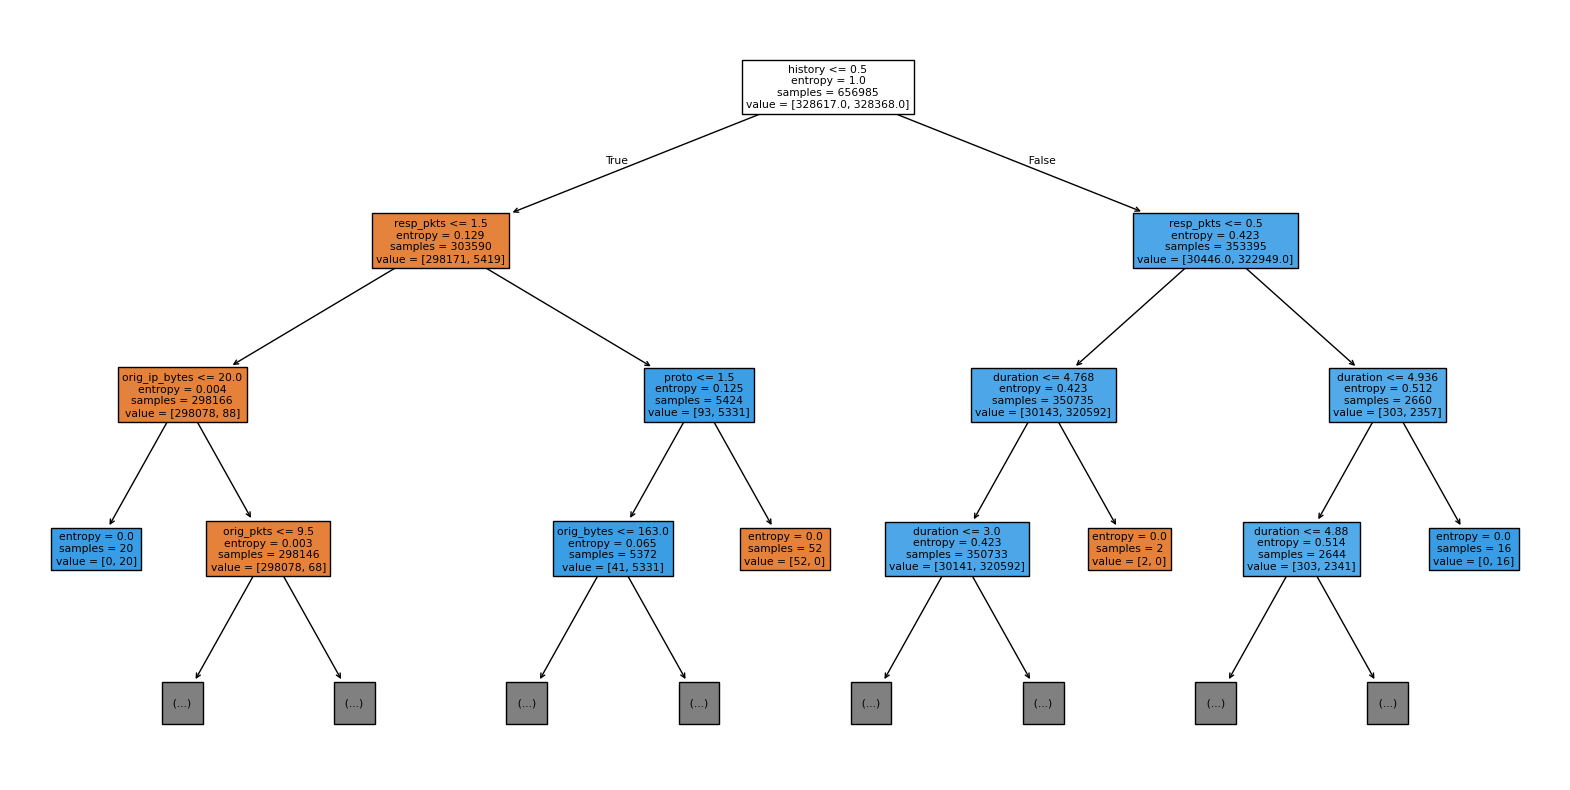

Number of nodes: 3155


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1) 70% training and 30% test [cite: 52]
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# 2) Decision Tree based on entropy [cite: 53]
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)

# Plot the tree [cite: 54]
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(clf_entropy, filled=True, feature_names=features.columns, max_depth=3)
plt.show()

print(f"Number of nodes: {clf_entropy.tree_.node_count}") # [cite: 54]

Confusion Matrix:
 [[127688  12970]
 [   193 140714]]
Accuracy Score: 0.9532505815708628


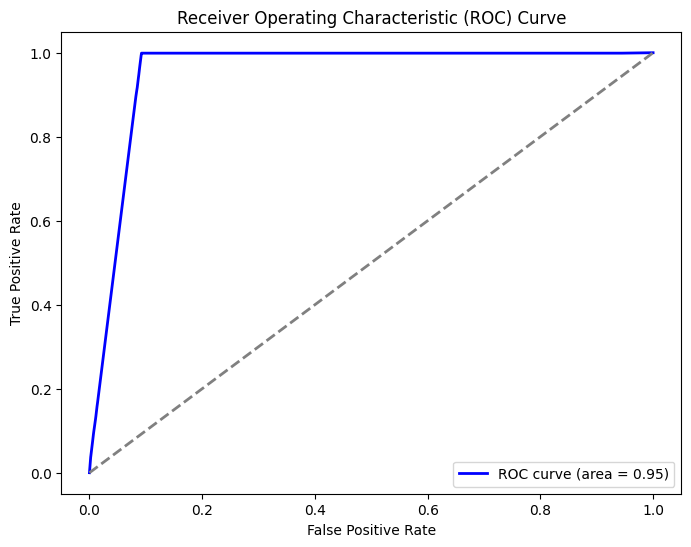

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# 3) Get performance using confusion matrix and accuracy_score
y_pred = clf_entropy.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Plot the ROC curve
y_probs = clf_entropy.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [27]:
from sklearn.tree import export_text

# 4) List the IF-THEN rules
tree_rules = export_text(clf_entropy, feature_names=list(features.columns))
print("Decision Tree IF-THEN Rules:\n")
print(tree_rules)

Decision Tree IF-THEN Rules:

|--- history <= 0.50
|   |--- resp_pkts <= 1.50
|   |   |--- orig_ip_bytes <= 20.00
|   |   |   |--- class: 1
|   |   |--- orig_ip_bytes >  20.00
|   |   |   |--- orig_pkts <= 9.50
|   |   |   |   |--- conn_state <= 9.50
|   |   |   |   |   |--- duration <= 100.02
|   |   |   |   |   |   |--- orig_ip_bytes <= 98.00
|   |   |   |   |   |   |   |--- orig_ip_bytes <= 48.00
|   |   |   |   |   |   |   |   |--- resp_ip_bytes <= 46.00
|   |   |   |   |   |   |   |   |   |--- proto <= 1.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- proto >  1.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- resp_ip_bytes >  46.00
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- orig_ip_bytes >  48.00
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- orig_ip_bytes >  98.00
|   |   |   |   |   |   |   |--- orig_ip_bytes <= 102.0

In [28]:
from sklearn.feature_selection import mutual_info_classif

# 5) Compute mutual information between each feature and the target
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# Create a Series for easy viewing
mi_results = pd.Series(mi_scores, index=features.columns).sort_values(ascending=False)
print("Mutual Information Scores per Feature:\n")
print(mi_results)

# Select top two features based on mutual information
top_two_features = mi_results.index[:2].tolist()
print(f"\nTop two selected features: {top_two_features}")

# Create new datasets with only these two features
X_train_reduced = X_train[top_two_features]
X_test_reduced = X_test[top_two_features]

Mutual Information Scores per Feature:

proto            0.584205
orig_ip_bytes    0.560771
history          0.542311
orig_pkts        0.133026
duration         0.096512
conn_state       0.080170
orig_bytes       0.010858
resp_ip_bytes    0.010100
resp_bytes       0.009203
resp_pkts        0.005452
service          0.002254
dtype: float64

Top two selected features: ['proto', 'orig_ip_bytes']


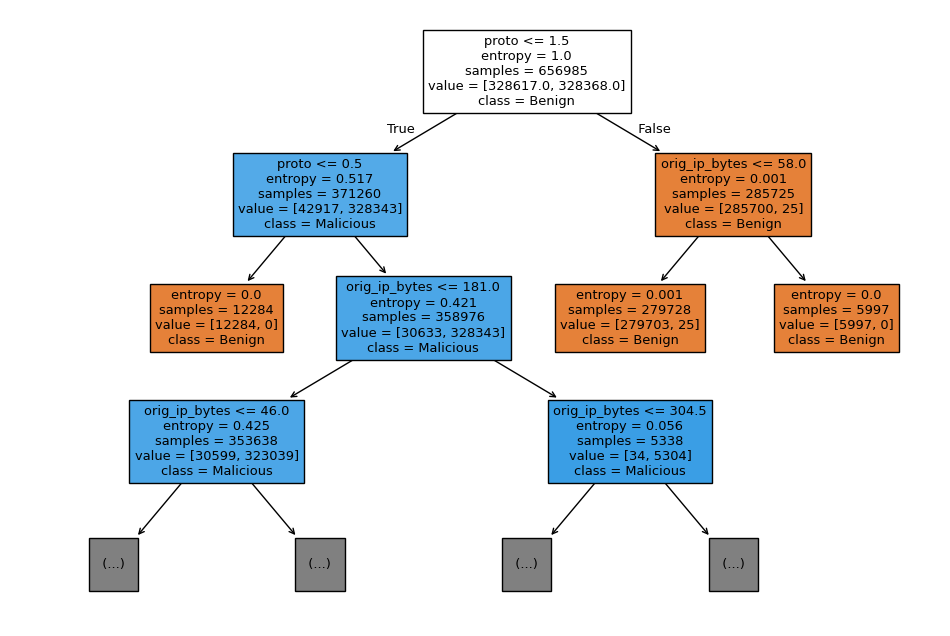

Number of nodes in the reduced tree: 143

Confusion Matrix (Reduced Model):
 [[127657  13001]
 [    13 140894]]
Accuracy Score (Reduced Model): 0.9537797666613393


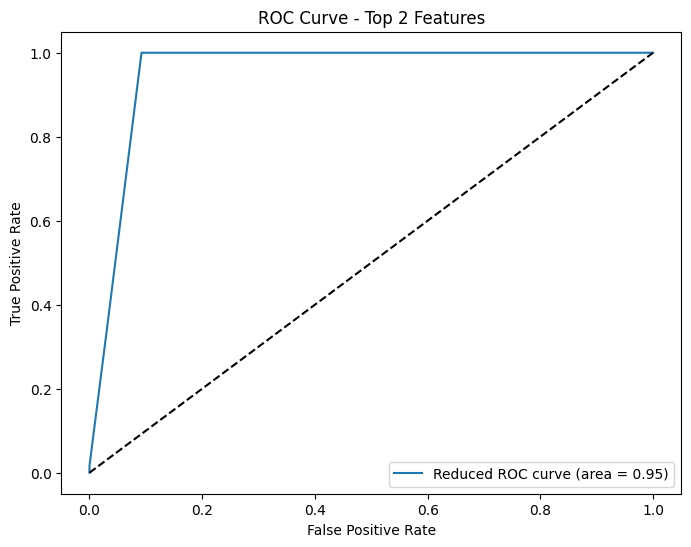

In [29]:
# 6) Design a new decision tree classifier based on top 2 features and entropy
clf_reduced = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_reduced.fit(X_train_reduced, y_train)

# Plot the reduced design tree
plt.figure(figsize=(12,8))
plot_tree(clf_reduced, filled=True, feature_names=top_two_features,
          class_names=['Benign', 'Malicious'], max_depth=3)
plt.show()

# How many nodes does this tree have?
print(f"Number of nodes in the reduced tree: {clf_reduced.tree_.node_count}")

# 7) Performance using confusion matrix and accuracy_score for the reduced model
y_pred_reduced = clf_reduced.predict(X_test_reduced)
print("\nConfusion Matrix (Reduced Model):\n", confusion_matrix(y_test, y_pred_reduced))
print("Accuracy Score (Reduced Model):", accuracy_score(y_test, y_pred_reduced))

# Plot the ROC curve for the reduced model
y_probs_red = clf_reduced.predict_proba(X_test_reduced)[:, 1]
fpr_red, tpr_red, _ = roc_curve(y_test, y_probs_red)
roc_auc_red = auc(fpr_red, tpr_red)

plt.figure(figsize=(8,6))
plt.plot(fpr_red, tpr_red, label=f'Reduced ROC curve (area = {roc_auc_red:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Top 2 Features')
plt.legend(loc="lower right")
plt.show()

In [30]:
# 8) List the IF-THEN rules using export_text for the reduced model
reduced_rules = export_text(clf_reduced, feature_names=top_two_features)
print("Simplified IF-THEN Rules:\n")
print(reduced_rules)

Simplified IF-THEN Rules:

|--- proto <= 1.50
|   |--- proto <= 0.50
|   |   |--- class: 0
|   |--- proto >  0.50
|   |   |--- orig_ip_bytes <= 181.00
|   |   |   |--- orig_ip_bytes <= 46.00
|   |   |   |   |--- orig_ip_bytes <= 20.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- orig_ip_bytes >  20.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- orig_ip_bytes >  46.00
|   |   |   |   |--- orig_ip_bytes <= 54.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- orig_ip_bytes >  54.00
|   |   |   |   |   |--- orig_ip_bytes <= 58.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- orig_ip_bytes >  58.00
|   |   |   |   |   |   |--- orig_ip_bytes <= 162.00
|   |   |   |   |   |   |   |--- orig_ip_bytes <= 64.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- orig_ip_bytes >  64.50
|   |   |   |   |   |   |   |   |--- orig_ip_bytes <= 86.00
|   |   |   |   |   |   |   |   |   |--- orig_ip_bytes <= 75.00
|   |   |   |   |   | 

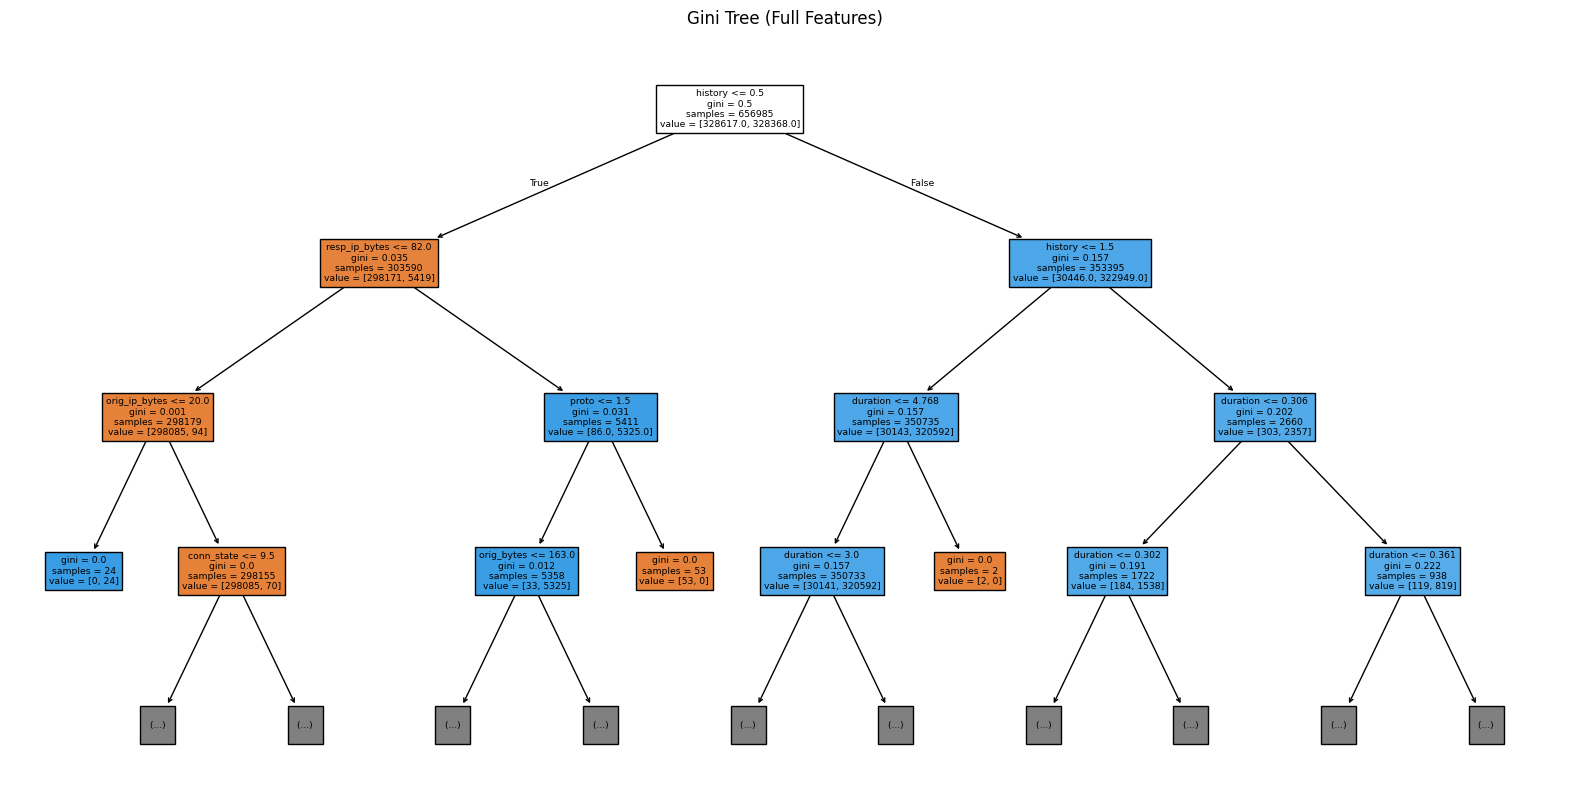

Full Gini Tree Node Count: 3167

Gini Confusion Matrix:
 [[127689  12969]
 [   196 140711]]
Gini Accuracy Score: 0.953243478415286
Gini ROC AUC: 0.95

Gini IF-THEN Rules:
 |--- history <= 0.50
|   |--- resp_ip_bytes <= 82.00
|   |   |--- orig_ip_bytes <= 20.00
|   |   |   |--- class: 1
|   |   |--- orig_ip_bytes >  20.00
|   |   |   |--- conn_state <= 9.50
|   |   |   |   |--- orig_pkts <= 9.50
|   |   |   |   |   |--- duration <= 147.34
|   |   |   |   |   |   |--- resp_pkts <= 1.50
|   |   |   |   |   |   |   |--- duration <= 100.02
|   |   |   |   |   |   |   |   |--- orig_ip_bytes <= 98.00
|   |   |   |   |   |   |   |   |   |--- orig_ip_bytes <= 48.00
|   |   |   |   |   |   |   |   |   |   |--- resp_ip_bytes <= 46.00
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- resp_ip_bytes >  46.00
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- orig_ip_bytes >  48.00


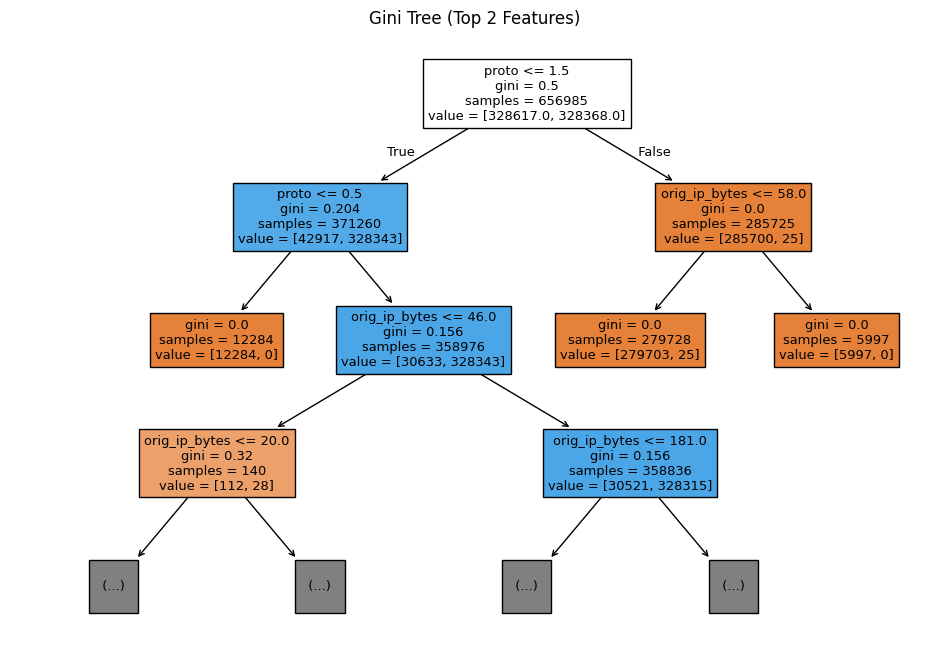

Reduced Gini Tree Node Count: 143

Reduced Gini Accuracy: 0.9537797666613393

Reduced Gini Rules:
 |--- proto <= 1.50
|   |--- proto <= 0.50
|   |   |--- class: 0
|   |--- proto >  0.50
|   |   |--- orig_ip_bytes <= 46.00
|   |   |   |--- orig_ip_bytes <= 20.00
|   |   |   |   |--- class: 1
|   |   |   |--- orig_ip_bytes >  20.00
|   |   |   |   |--- class: 0
|   |   |--- orig_ip_bytes >  46.00
|   |   |   |--- orig_ip_bytes <= 181.00
|   |   |   |   |--- orig_ip_bytes <= 54.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- orig_ip_bytes >  54.00
|   |   |   |   |   |--- orig_ip_bytes <= 58.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- orig_ip_bytes >  58.00
|   |   |   |   |   |   |--- orig_ip_bytes <= 162.00
|   |   |   |   |   |   |   |--- orig_ip_bytes <= 64.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- orig_ip_bytes >  64.50
|   |   |   |   |   |   |   |   |--- orig_ip_bytes <= 86.00
|   |   |   |   |   |   |   |   | 

In [31]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# --- 9.1 & 9.2: Initial Tree with Gini ---
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)

# Plot and node count
plt.figure(figsize=(20,10))
plot_tree(clf_gini, filled=True, feature_names=features.columns, max_depth=3)
plt.title("Gini Tree (Full Features)")
plt.show()
print(f"Full Gini Tree Node Count: {clf_gini.tree_.node_count}")

# --- 9.3: Gini Performance ---
y_pred_gini = clf_gini.predict(X_test)
print("\nGini Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gini))
print("Gini Accuracy Score:", accuracy_score(y_test, y_pred_gini))

# ROC for Gini
y_probs_gini = clf_gini.predict_proba(X_test)[:, 1]
fpr_g, tpr_g, _ = roc_curve(y_test, y_probs_gini)
print(f"Gini ROC AUC: {auc(fpr_g, tpr_g):.2f}")

# --- 9.4: Gini Rules ---
print("\nGini IF-THEN Rules:\n", export_text(clf_gini, feature_names=list(features.columns)))

# --- 9.5 & 9.6: Reduced Gini Tree (Top 2 Features) ---
# (Note: We use the same top_two_features found from Mutual Information earlier)
clf_gini_red = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini_red.fit(X_train_reduced, y_train)

plt.figure(figsize=(12,8))
plot_tree(clf_gini_red, filled=True, feature_names=top_two_features, max_depth=3)
plt.title("Gini Tree (Top 2 Features)")
plt.show()
print(f"Reduced Gini Tree Node Count: {clf_gini_red.tree_.node_count}")

# --- 9.7 & 9.8: Reduced Gini Performance & Rules ---
y_pred_ginired = clf_gini_red.predict(X_test_reduced)
print("\nReduced Gini Accuracy:", accuracy_score(y_test, y_pred_ginired))
print("\nReduced Gini Rules:\n", export_text(clf_gini_red, feature_names=top_two_features))